In [16]:
import networkx as nx
import pandas as pd
import urllib
import matplotlib.pyplot as plt

In [9]:
with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/final-project/voting-data/df_votes_enriched.csv") as response:
    df = pd.read_csv(response)

In [ ]:
print(df['Period'].unique())

[68 67 69 66 65 70 71]


In [13]:
#Let's just work with one period for now 
# We use period 70
df = df[df['Period'] == 70]

In [14]:
# For each unique politician create a DF
# For each other unique politician
# Count how many voting id´s they share
# Count how many voting id's they have the same value in
# Cakculate agreement percentage
# Add it as edges to a graph
G = nx.Graph()
#Let's do some agreement stuff
# def create_network_from_theme(df):
#     return G

#WE could also already have filtered the dataframe here by theme or something like that. It's probably the smartest thing to do.
politician_list = df['politician'].unique()
for idx, politician in enumerate(politician_list):

    df_pol = df[df['politician'] == politician][['voting_id', 'vote_type']]

    for other_politician in politician_list[idx+1:]: #Look at remaining politicians to avoid double work
        df_other = df[df['politician'] == other_politician][['voting_id', 'vote_type']]
        
        #WE NEED TO ADD SOMETHING ABOUT THE THEME HERE?
        total_df = df_pol.merge(df_other, on='voting_id', how='inner') #Count how many voting_id's they share
        agree_df = df_pol.merge(df_other, on=['voting_id', 'vote_type'], how='inner') #Count share where they also voted the same
        total = len(total_df)
        agree = len(agree_df)

        agree_percent = agree / total if total > 0 else 0
        G.add_edge(politician, other_politician, weight=agree_percent)

In [15]:
# DOES THIS EVEN MAKE SENSE?
g_df = nx.to_pandas_edgelist(G)

# g_df['weight']
# g_df[g_df['weight'] > agreement_threshold]

,voting_id,party,politician,vote_type,Period,vedtaget,Møde.dato
708500,7154,Socialdemokratiet,Nicolai Wammen,1,70,True,2019-06-21 13:00:00
708501,7154,Dansk Folkeparti,Alex Ahrendtsen,3,70,True,2019-06-21 13:00:00
708502,7154,Venstre,Karsten Lauritzen,1,70,True,2019-06-21 13:00:00
708503,7154,Socialdemokratiet,Henrik Sass Larsen,3,70,True,2019-06-21 13:00:00
708504,7154,Danmarksdemokraterne,Søren Espersen,3,70,True,2019-06-21 13:00:00
...,...,...,...,...,...,...,...
877295,9001,Enhedslisten,Søren Egge Rasmussen,3,70,True,2022-10-06 09:00:00
877296,9001,Uden for folketingsgrupperne,Naser Khader,2,70,True,2022-10-06 09:00:00
877297,9001,Det Konservative Folkeparti,Rasmus Jarlov,2,70,True,2022-10-06 09:00:00
877298,9001,Enhedslisten,Jette Gottlieb,1,70,True,2022-10-06 09:00:00


5995 299


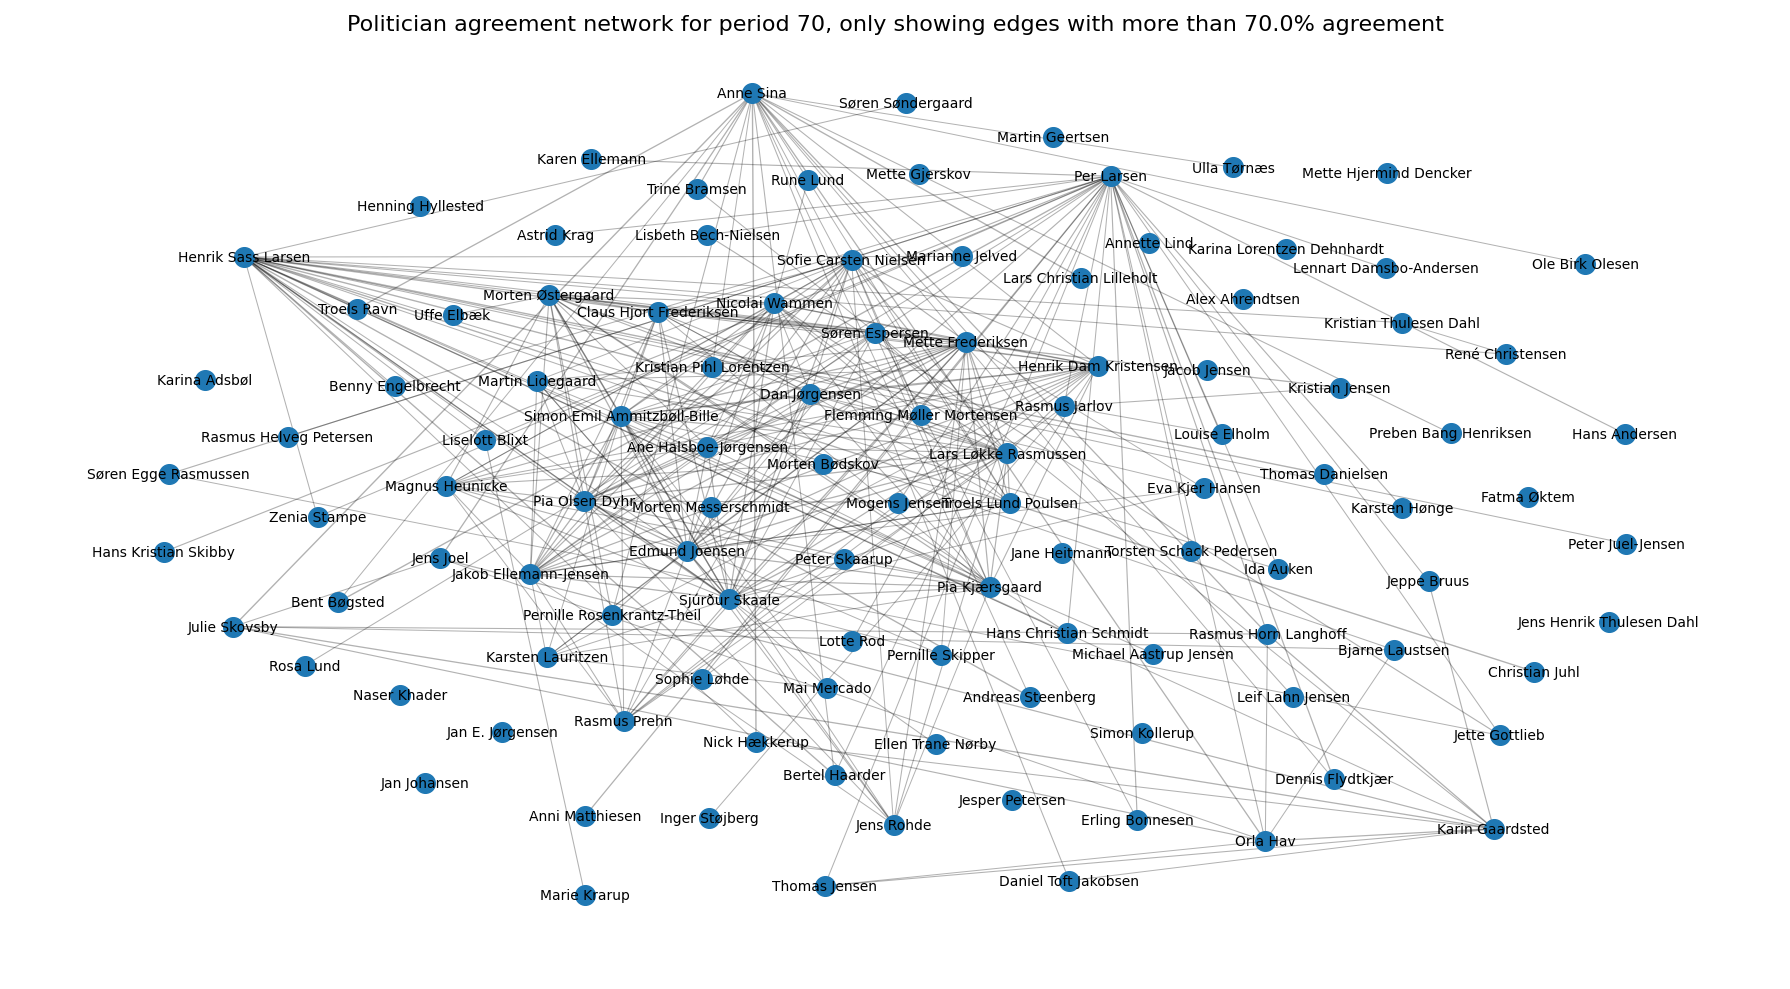

In [22]:
figure, axs = plt.subplots(1,1,figsize = (18,10)) #Width, Height


# Some arguments for the visualization
period = df['Period'].unique() #We should maybe convert this to a time-period instead



pos = nx.forceatlas2_layout(G
                                        , seed = 42
                                        , weight = "weight"
                                        )

# nodes
agreement_threshold = 0.7
df_draw = g_df[g_df['weight'] > agreement_threshold]

print(len(g_df), len(df_draw))

#Get the edges and widths to draw
edges = list(zip(df_draw['source'], df_draw['target']))
edge_widths = df_draw['weight'].tolist()


nx.draw_networkx_nodes(G, pos, node_size=200, ax = axs)

# edges
nx.draw_networkx_edges(G, pos, edgelist=edges, width=[w * 1 for w in edge_widths], alpha = 0.3, ax = axs)


# node labels
nx.draw_networkx_labels(G, pos, font_size=10, ax = axs)


# ax.margins(0.08)
plt.axis("off")
plt.tight_layout()
plt.suptitle(f"Politician agreement network for period {period[0]}, only showing edges with more than {agreement_threshold*100}% agreement", fontsize = 16)
plt.show()

In [ ]:
party_colors = {
    'Socialdemokraterne': '#E3515D',      # Red/Pink (Social Democrats)
    'Venstre': '#005392',                  # Blue (Liberals)
    'Det Konservative Folkeparti': '#429969',  # Green (Conservatives)
    'Socialistisk Folkeparti': '#9C1D2E',  # Dark Red (Socialist People's Party)
    'Radikale Venstre': '#EB4295',         # Magenta/Pink (Social Liberals)
    'Dansk Folkeparti': '#EAC73E',         # Yellow (Danish People's Party)
    'Enhedslisten': '#E6801A',             # Orange/Red (Red-Green Alliance)
    
    # Newer/smaller parties
    'Liberal Alliance': '#3FB2BE',         # Turquoise/Cyan
    'Alternativet': '#AEFEAF',             # Light Green
    'Nye Borgerlige': '#05454F',           # Dark Teal/Blue
    'Moderaterne': '#53307C',              # Purple
    'Danmarksdemokraterne': '#00746A',     # Teal/Green
    
    # Historical parties
    'Kristendemokraterne': '#543D7A',      # Purple
    'Centrum-Demokraterne': '#8B8474',     # Gray
    'Fremskridtspartiet': '#3FB2BE',       # Similar to Liberal Alliance
}